In [29]:
## import dependencies
import os
import re
import sys
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

## Add the path to the DiscEvolution directory
sys.path.append('/Users/ben/Downloads/Planet Formation/Code/DiscEvolution Core Accretion')

## import DiscEvolution modules
from DiscEvolution.constants import *
from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import IrradiatedEOS, LocallyIsothermalEOS, SimpleDiscEOS
from DiscEvolution.disc import *
from DiscEvolution.viscous_evolution import ViscousEvolution, ViscousEvolutionFV, LBP_Solution, HybridWindModel, TaboneSolution
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.dust import *
from DiscEvolution.dust import PlanetesimalFormation
from DiscEvolution.planet_formation import *
from DiscEvolution.diffusion import TracerDiffusion
from DiscEvolution.opacity import Tazzari2016
from DiscEvolution.chemistry import *

## Methods to Read and Load Data

In [30]:
## Method to read data from an HDF5 dataset or group

def read_hdf5_array(obj):
    """
    Read data from either an HDF5 dataset or an HDF5 group.
    """

    ## Normal case (the data are stored as one HDF5 dataset)
    if isinstance(obj, h5py.Dataset):
        return np.array(obj)

    ## Ragged case (the data are stored as a group)
    elif isinstance(obj, h5py.Group):
        values = []

        for key in sorted(obj.keys(), key = int):
            values.append(np.array(obj[key]))

        return values

    ## Raise an error if an unexpected HDF5 object is encountered
    else:
        raise TypeError(f"Unexpected HDF5 object type: {type(obj)}")

## Method to load data from an HDF5 file, together with the config used to produce it

def load_data(data_dir, config_dir):
    """
    Load a disc evolution output file (HDF5 only).

    Parameters:
        data_dir: Path to the HDF5 output file.
        config_dir: Path to the JSON config file used for the run.

    Returns:
        data: Dictionary containing the simulation output.
        config: Dictionary containing the simulation config file.
    """

    data = {}

    ## Load the configuration file

    with open(config_dir, "r") as f:
        config = json.load(f)

    ## Open the HDF5 file in read-only mode
    with h5py.File(data_dir, "r") as f:

        ## -----------------------
        ## General simulation data
        ## -----------------------

        general_keys = [
            "R",
            "t",
            "disk_Mdot_star",
            "disk_Mass",
            "Tc",
            "Sigc"]

        for key in general_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = np.array(f[key])

        ## ---------------
        ## Alpha viscosity
        ## ---------------

        if "alpha_SS" in f.attrs:
            data["alpha_SS"] = float(f.attrs["alpha_SS"])

        elif "alpha_SS" in f:
            data["alpha_SS"] = float(f["alpha_SS"][()])

        if config["winds"]["on"]:
            data["psi"] = config["winds"]["psi_DW"]

        ## -------------
        ## Disk profiles
        ## -------------

        disk_keys = [
            "T",
            "time_snap",
            "Sigma_G",
            "Sigma_dust",
            "Sigma_pebbles",
            "Sigma_planetesimals",
            "Vdrift_grains",
            "Vdrift_pebbles",
            "St_grains",
            "St_pebbles",
            "St_planetesimals",
            "e_planetesimals",
            "i_planetesimals",
            "de2_dt",
            "di2_dt",
            "de2_dt_drag",
            "di2_dt_drag",
            "de2_dt_VS_embryo",
            "di2_dt_VS_embryo",
            "de2_dt_VS_pltsml",
            "di2_dt_VS_pltsml",
            "de2_dt_DF",
            "di2_dt_DF"]

        for key in disk_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = read_hdf5_array(f[key])

        ## -----------
        ## Planet data
        ## -----------

        if config["planets"]["include_planets"]:
            planet_keys = [
                "Mcs",
                "Mes",
                "Rp",
                "disk_Mdot_p",
                "Mdot_planetesimal",
                "Mdot_pebble_core",
                "Mdot_pebble_env",
                "Mdot_migration",
                "Mdot_gas",
                "M_iso_planetesimal",
                "M_iso_pebble",
                "X_cores",
                "X_envs",
                "t_form"]

            for key in planet_keys:
                if key in f:
                    data[key] = read_hdf5_array(f[key])

    return data, config

## Data and Plotting Directories

In [31]:
## Load data and config file

data_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260905_2127_psi10_Mdot1.0e-08_M0.1_Rd50.h5"
config_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Config/20260905_full_accretion.json"

data, config = load_data(data_dir, config_dir)

In [32]:
## Figure output

figure_dir = f"/Users/ben/Downloads/Planet Formation/DiscEvolution Plots/"

if not(os.path.exists(figure_dir)):
        os.makedirs(figure_dir)

save_figures = True

## Extract Data

In [33]:
## Disc profiles
R = data["R"]
alpha = data["alpha_SS"]

## Surface density profiles
Sigma_G = data["Sigma_G"]
Sigma_grains = data["Sigma_dust"]
Sigma_pebble = data["Sigma_pebbles"]

if config["planetesimal"]["active"]:
    Sigma_planetesimal = data["Sigma_planetesimals"]

## Temperature profiles
T = data["T"]

## Eccentricity and inclination profiles
if config["planetesimal"]["active"]:
    e_planetesimal = data["e_planetesimals"]
    i_planetesimal = data["i_planetesimals"]

## Eccentricity and inclination derivatives
if config["planetesimal"]["active"]:
    if config["planetesimal"]["drag"]:
        de2_dt_drag = data["de2_dt_drag"]
        di2_dt_drag = data["di2_dt_drag"]

    if config["planetesimal"]["VS_embryo"]:
        de2_dt_VS_embryo = data["de2_dt_VS_embryo"]
        di2_dt_VS_embryo = data["di2_dt_VS_embryo"]

    if config["planetesimal"]["VS_pltsml"]:
        de2_dt_VS_pltsml = data["de2_dt_VS_pltsml"]
        di2_dt_VS_pltsml = data["di2_dt_VS_pltsml"]

    if config["planetesimal"]["DF"]:
        de2_dt_DF = data["de2_dt_DF"]
        di2_dt_DF = data["di2_dt_DF"]

    if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
        de2_dt = data["de2_dt"]
        di2_dt = data["di2_dt"]

## Accretion rates
if config["planets"]["include_planets"]:
    if config["planets"]["planetesimal_accretion_insitu"]:
        Mdot_planetesimal = data["Mdot_planetesimal"]

    if config["planets"]["planetesimal_accretion_migrate"]:
        Mdot_migration = data["Mdot_migration"]

    if config["planets"]["pebble_accretion"]:
        Mdot_pebble_core = data["Mdot_pebble_core"]
        Mdot_pebble_env = data["Mdot_pebble_env"]

    if config["planets"]["gas_accretion"]:
        Mdot_gas = data["Mdot_gas"]

## Planet properties
if config["planets"]["include_planets"]:
    Rp = data["Rp"]
    Mcs = data["Mcs"]
    Mes = data["Mes"]
    Mp = Mcs + Mes
    t_form = data["t_form"]
    R_form = config["planets"]["Rp"]

    if config["planets"]["planetesimal_accretion_insitu"]:
        M_iso_planetesimal = data["M_iso_planetesimal"]

    if config["planets"]["pebble_accretion"]:
        M_iso_pebble = data["M_iso_pebble"]

## Time data
t = data["t"]
t_interval = config["simulation"]["t_interval"]

## Plot Formatting Options

In [34]:
## Matplotlib colors

n_times = len(t_interval)

color_blues = plt.cm.Blues(np.linspace(1, 0.4, n_times))
color_greys = plt.cm.Greys(np.linspace(1, 0.4, n_times))
color_greens = plt.cm.Greens(np.linspace(1, 0.4, n_times))
color_reds = plt.cm.Reds(np.linspace(1, 0.4, n_times))

## Global plot style

plt.rcParams.update({
    'axes.linewidth': 2.0,
    'axes.labelsize': 14,
    'axes.labelweight': 'normal',
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12})

## Method to bold the tick labels

def bold_ticks(*axes):
    for ax in axes:
        labels = (ax.get_xticklabels() + ax.get_yticklabels()
            + ax.get_xticklabels(minor = True) + ax.get_yticklabels(minor = True))

        for label in labels:
            label.set_fontweight('bold')

## Eccentricity Derivatives

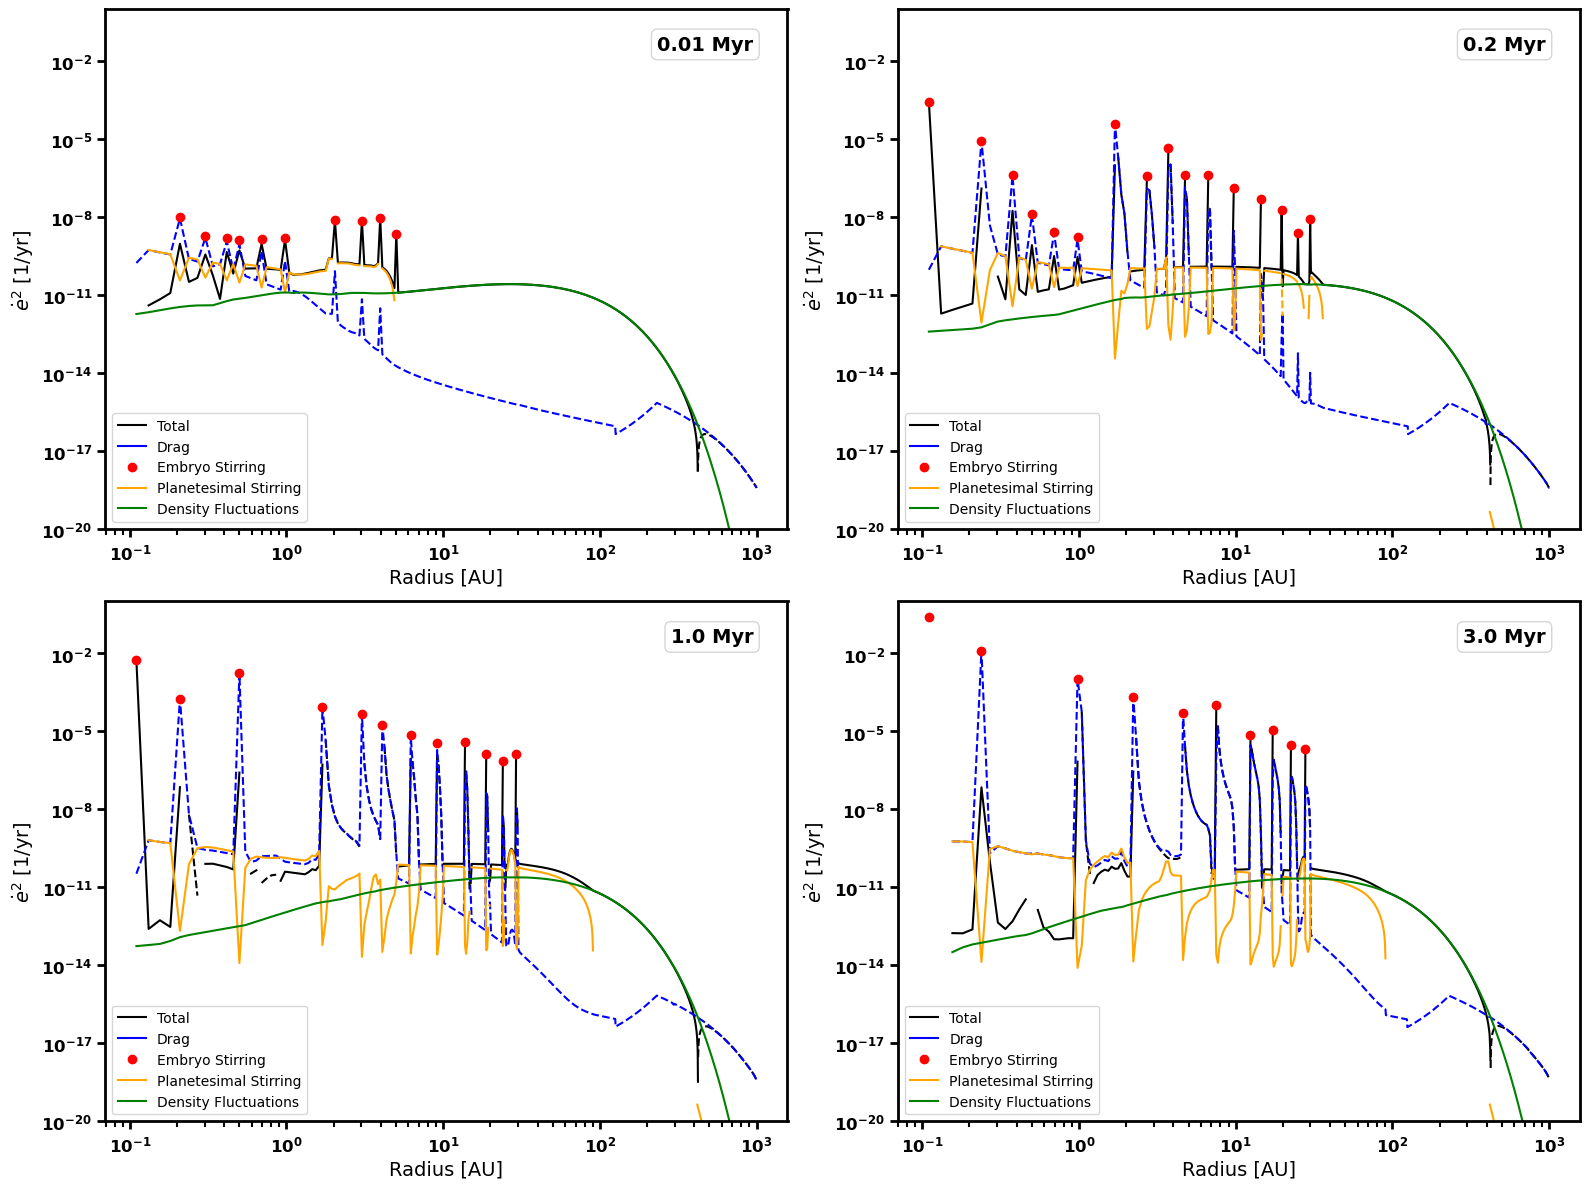

In [35]:
fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

times = [0.01, 0.2, 1.0, 3.0]

for i in range(2):
    for j in range(2):
        time = times[i * 2 + j]

        ## Find the index of the closest time in t_interval
        idx = int(np.argmin(np.abs(t_interval - np.full(len(t_interval), time))))

        ## Eccentricity derivatives
        if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
            ax[i, j].plot(R, np.where(de2_dt[idx] > 0, de2_dt[idx], np.nan), color = 'black', linestyle = '-', label = 'Total')
            ax[i, j].plot(R, np.where(de2_dt[idx] < 0, -1 * de2_dt[idx], np.nan), color = 'black', linestyle = '--')
        
        ## Drag
        if config["planetesimal"]["drag"]:
            ax[i, j].plot(R, np.where(de2_dt_drag[idx] > 0, de2_dt_drag[idx], np.nan), color = 'blue', linestyle = '-', label = 'Drag')
            ax[i, j].plot(R, np.where(de2_dt_drag[idx] < 0, -1 * de2_dt_drag[idx], np.nan), color = 'blue', linestyle = '--')

        ## Embryo stirring
        if config["planetesimal"]["VS_embryo"]:
            ax[i, j].plot(R, np.where(de2_dt_VS_embryo[idx] > 0, de2_dt_VS_embryo[idx], np.nan), color = 'red', linestyle = 'None', marker = 'o', label = 'Embryo Stirring')
            ax[i, j].plot(R, np.where(de2_dt_VS_embryo[idx] < 0, -1 * de2_dt_VS_embryo[idx], np.nan), color = 'red', linestyle = 'None', marker = 's')

        ## Planetesimal stirring
        if config["planetesimal"]["VS_pltsml"]:
            ax[i, j].plot(R, np.where(de2_dt_VS_pltsml[idx] > 0, de2_dt_VS_pltsml[idx], np.nan), color = 'orange', linestyle = '-', label = 'Planetesimal Stirring')
            ax[i, j].plot(R, np.where(de2_dt_VS_pltsml[idx] < 0, -1 * de2_dt_VS_pltsml[idx], np.nan), color = 'orange', linestyle = '--')

        ## Density fluctuations
        if config["planetesimal"]["DF"]:
            ax[i, j].plot(R, np.where(de2_dt_DF[idx] > 0, de2_dt_DF[idx], np.nan), color = 'green', linestyle = '-', label = 'Density Fluctuations')
            ax[i, j].plot(R, np.where(de2_dt_DF[idx] < 0, -1 * de2_dt_DF[idx], np.nan), color = 'green', linestyle = '--')

        ax[i, j].set_xscale('log')
        ax[i, j].set_yscale('log')
        ax[i, j].set_ylim([1e-20, 1e0])
        ax[i, j].set_xlabel('Radius [AU]')
        ax[i, j].set_ylabel(r'$\dot e^2$ [1/yr]')
        ax[i, j].legend(loc = 'lower left', fontsize = 10)
    
        ax[i, j].text(0.95, 0.95, f'{time} Myr', transform = ax[i, j].transAxes,
            ha = 'right', va = 'top', fontsize = 14, fontweight = 'bold',
            bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))

bold_ticks(*ax.flat)

plt.tight_layout()

if save_figures:
    figure_path = os.path.join(figure_dir, "eccentricity_derivative_snapshots.png")
    plt.savefig(figure_path)

plt.show()

## Helper Functions

In [36]:
## Method to cumulatively integrate an accretion rate over time

def cumulative_mass_accreted(t, Mdot):
    """
    Cumulatively integrate the accretion rate over time to give accreted mass at each timestep.

    Parameters:
        t: Array of times, shape (n_times).
        Mdot: Array of accretion rates, shape (n_times) or (n_planets, n_times).

    Returns:
        Array of the same shape as Mdot giving the cumulative mass accreted up to each timestep.
    """

    Mdot = np.nan_to_num(Mdot, nan = 0.0)  # Replace NaN values with 0.0

    M = [0.0]

    for k in range(len(t) - 1):
        dt = t[k + 1] - t[k]
        M.append(M[-1] + Mdot[k] * dt)

    return np.array(M)

## Planet Accretion Histories

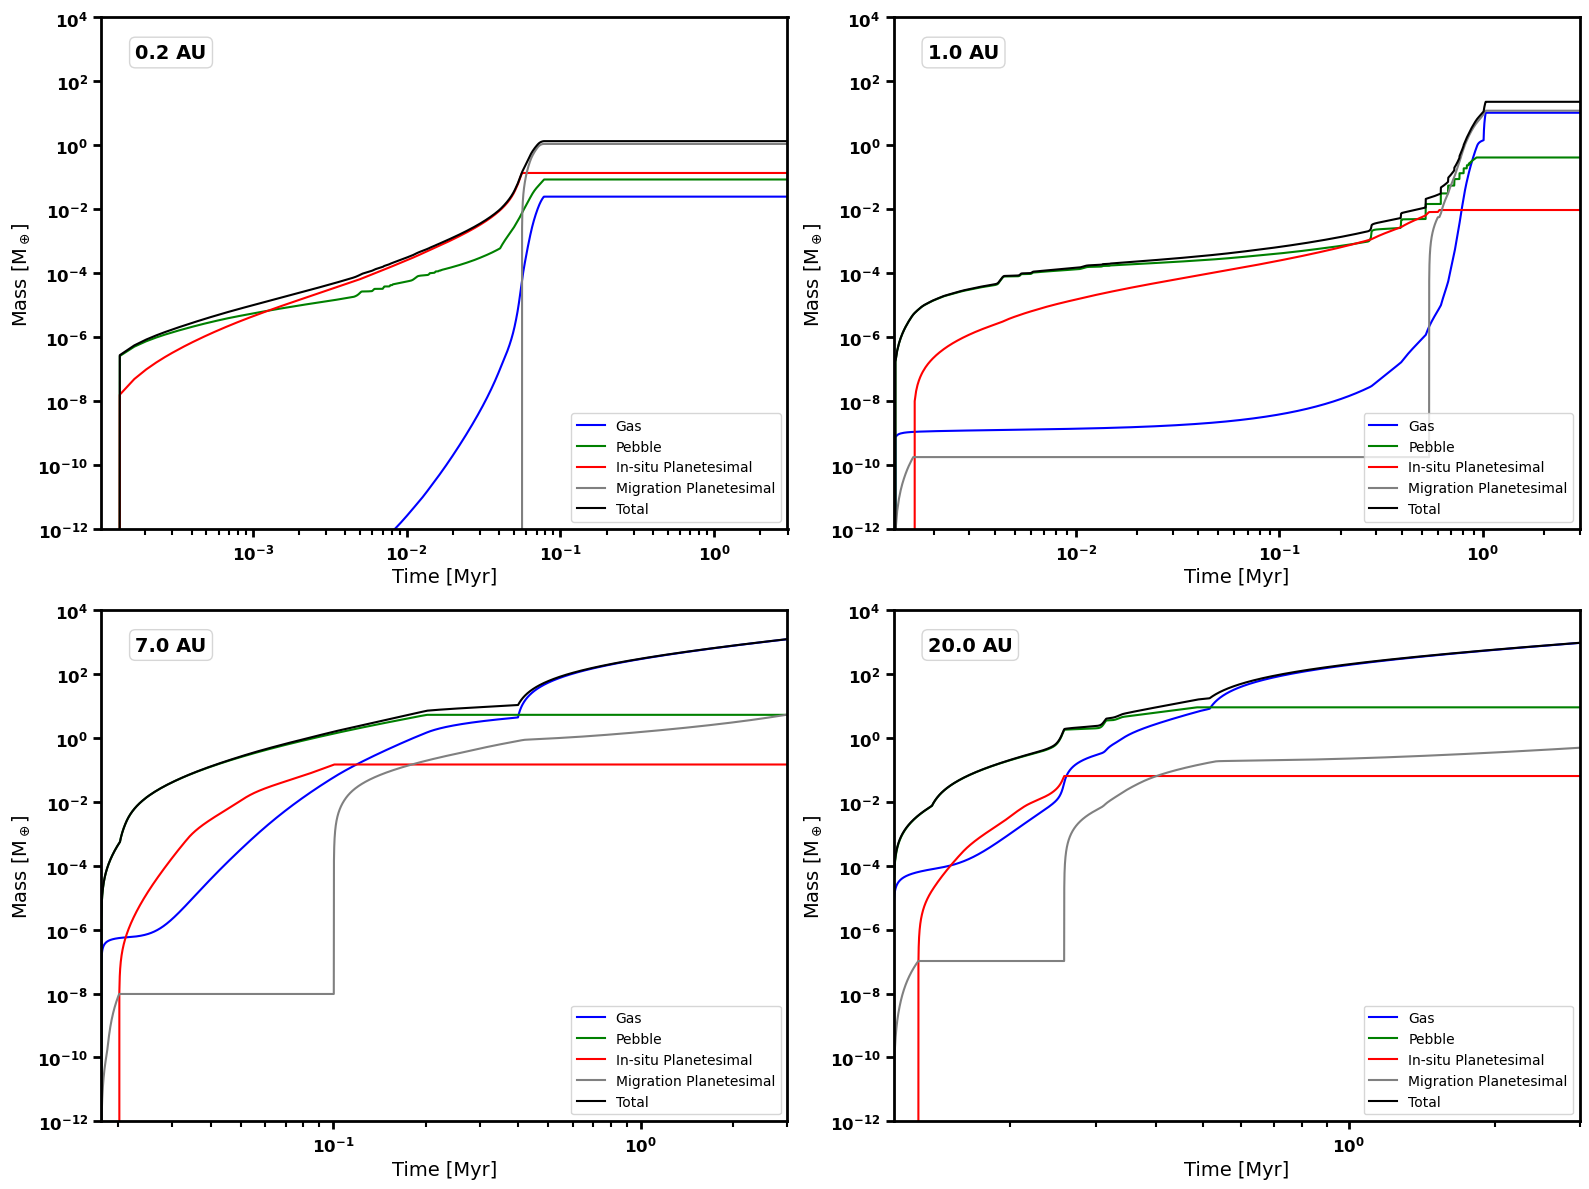

In [37]:
fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

Rs = [0.2, 1.0, 7.0, 20.0]

for i in range(2):
    for j in range(2):
        R_planet = Rs[i * 2 + j]

        ## Find the index of the planet
        idx = int(np.argmin(np.abs(R_form - np.full(len(R_form), R_planet))))

        ## Cumulative mass accreted
        
        M0 = np.nan_to_num(Mcs[idx][0], nan = 0.0) + np.nan_to_num(Mes[idx][0], nan = 0.0)
        M_tot = np.full_like(t, M0)
    
        if config["planets"]["gas_accretion"]:
            M_gas_accreted = cumulative_mass_accreted(t, Mdot_gas[idx])
            ax[i, j].plot(t / 1e6, M_gas_accreted, color = 'blue', label = f'Gas')
            M_tot += M_gas_accreted
    
        if config["planets"]["pebble_accretion"]:
            M_pebble_accreted = cumulative_mass_accreted(t, Mdot_pebble_core[idx] + Mdot_pebble_env[idx])
            ax[i, j].plot(t / 1e6, M_pebble_accreted, color = 'green', label = f'Pebble')
            M_tot += M_pebble_accreted
    
        if config["planets"]["planetesimal_accretion_insitu"]:
            M_planetesimal_accreted = cumulative_mass_accreted(t, Mdot_planetesimal[idx])
            ax[i, j].plot(t / 1e6, M_planetesimal_accreted, color = 'red', label = f'In-situ Planetesimal')
            M_tot += M_planetesimal_accreted
    
        if config["planets"]["planetesimal_accretion_migrate"]:
            M_migration_accreted = cumulative_mass_accreted(t, Mdot_migration[idx])
            ax[i, j].plot(t / 1e6, M_migration_accreted, color = 'grey', label = f'Migration Planetesimal')
            M_tot += M_migration_accreted
    
        ax[i, j].plot(t / 1e6, M_tot, color = 'black', label = f'Total')
    
        ax[i, j].set_xscale('log')
        ax[i, j].set_yscale('log')
        ax[i, j].set_xlim([t[~np.isnan(Rp[idx])][0]/ 1e6, 3])
        ax[i, j].set_ylim([1e-12, 1e4])
        ax[i, j].set_xlabel('Time [Myr]')
        ax[i, j].set_ylabel(r'Mass [M$_\oplus$]')
        ax[i, j].legend(loc = 'lower right', fontsize = 10)

        ax[i, j].text(0.05, 0.95, f'{R_planet} AU', transform = ax[i, j].transAxes,
                ha = 'left', va = 'top', fontsize = 14, fontweight = 'bold',
                bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))
        
bold_ticks(*ax.flat)

plt.tight_layout()

if save_figures:
    figure_path = os.path.join(figure_dir, "planet_accretion_histories.png")
    plt.savefig(figure_path)

plt.show()

## Planet Accretion Rates

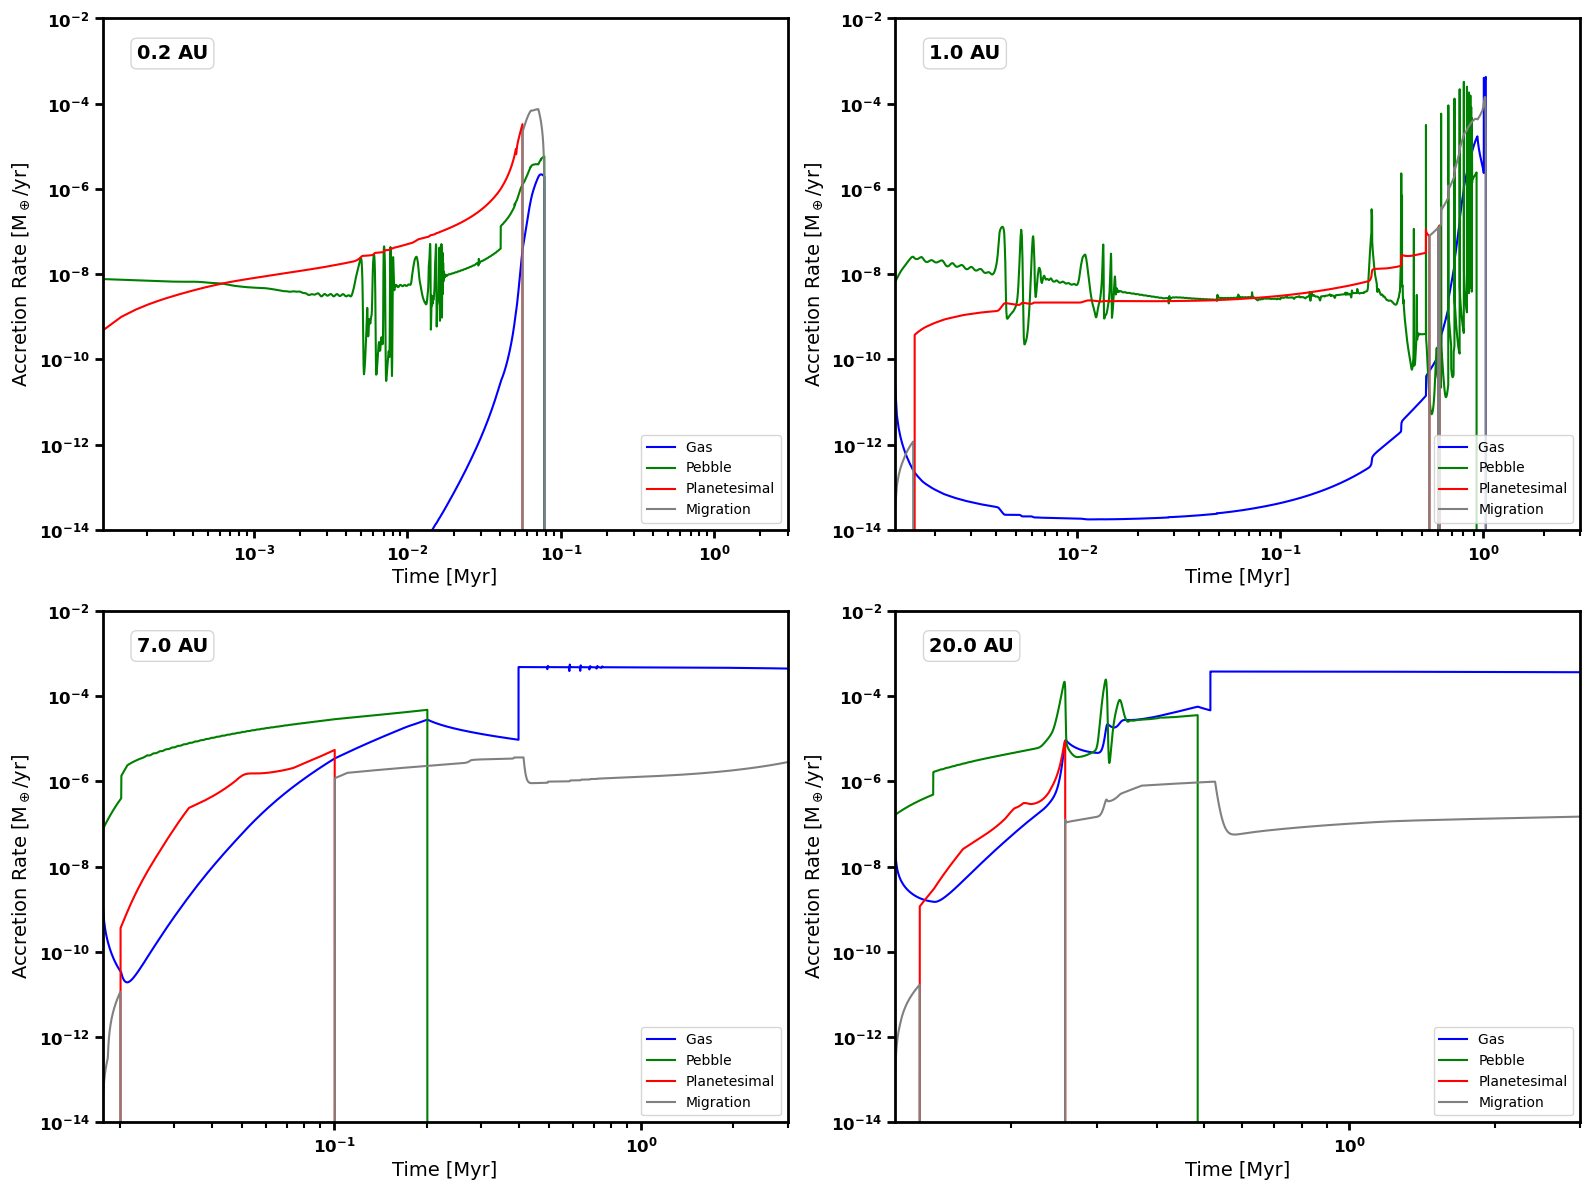

In [38]:
fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

Rs = [0.2, 1.0, 7.0, 20.0]

for i in range(2):
    for j in range(2):
        R_planet = Rs[i * 2 + j]

        ## Find the index of the planet
        idx = int(np.argmin(np.abs(R_form - np.full(len(R_form), R_planet))))

        ## Accretion rate evolution
        
        if config["planets"]["gas_accretion"]:
            ax[i, j].plot(t / 1e6, Mdot_gas[idx], color = 'blue', label = f'Gas ')
    
        if config["planets"]["pebble_accretion"]:
            ax[i, j].plot(t / 1e6, Mdot_pebble_core[idx] + Mdot_pebble_env[idx], color = 'green', label = f'Pebble')
    
        if config["planets"]["planetesimal_accretion_insitu"]:
            ax[i, j].plot(t / 1e6, Mdot_planetesimal[idx], color = 'red', label = f'Planetesimal')
    
        if config["planets"]["planetesimal_accretion_migrate"]:
            ax[i, j].plot(t / 1e6, Mdot_migration[idx], color = 'grey', label = f'Migration')
    
        ax[i, j].set_xscale('log')
        ax[i, j].set_yscale('log')
        ax[i, j].set_xlim([t[~np.isnan(Rp[idx])][0]/ 1e6, 3])
        ax[i, j].set_ylim([1e-14, 1e-2])
        ax[i, j].set_xlabel('Time [Myr]')
        ax[i, j].set_ylabel(r'Accretion Rate [M$_\oplus$/yr]')
        ax[i, j].legend(loc = 'lower right', fontsize = 10)

        ax[i, j].text(0.05, 0.95, f'{R_planet} AU', transform = ax[i, j].transAxes,
                        ha = 'left', va = 'top', fontsize = 14, fontweight = 'bold',
                        bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))
                
bold_ticks(*ax.flat)

plt.tight_layout()

if save_figures:
    figure_path = os.path.join(figure_dir, "planet_accretion_rates.png")
    plt.savefig(figure_path)

plt.show()